In [1]:
import numpy as np
import scanpy as sc
import pandas as pd
import seaborn as sns
import logging
import os
import sys
import traceback
import yaml
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from hydra import initialize, compose
from omegaconf import DictConfig
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
from torch.utils.data import DataLoader, TensorDataset

sys.path.insert(0, "../../../shared_utils")
from experiment_utils import get_forward_model

In [190]:
adata_mgk = sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/loops/data/loop5/adata_500k_residual.h5ad")

In [191]:
experiments = ["261",
                # "262",
                "263",
                "276", 
                "277", 
                "278"]
                # "279",
                # "280"]
adata_mgk = adata_mgk[adata_mgk.obs.experiment_number.isin(experiments)]

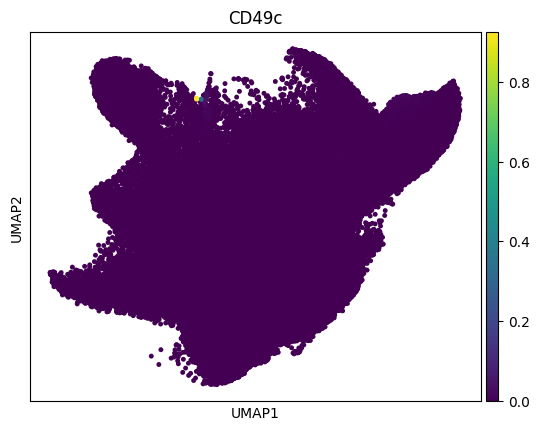

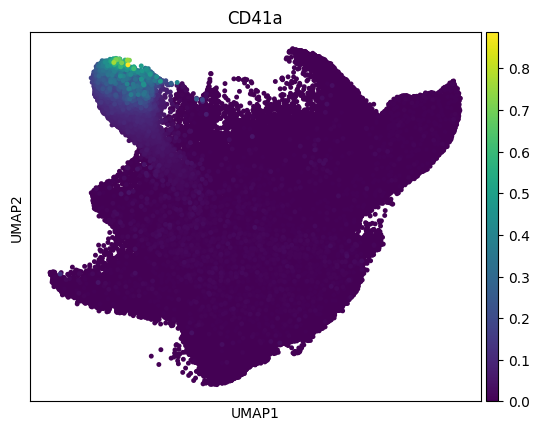

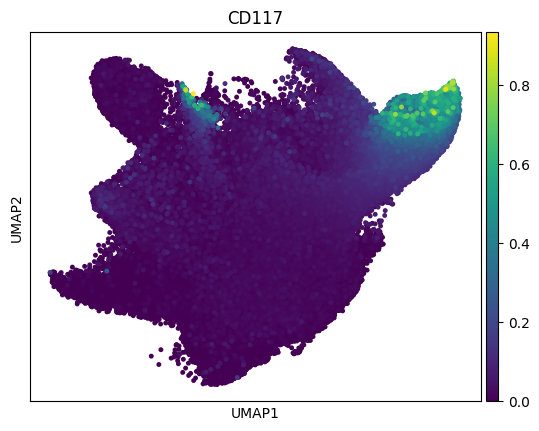

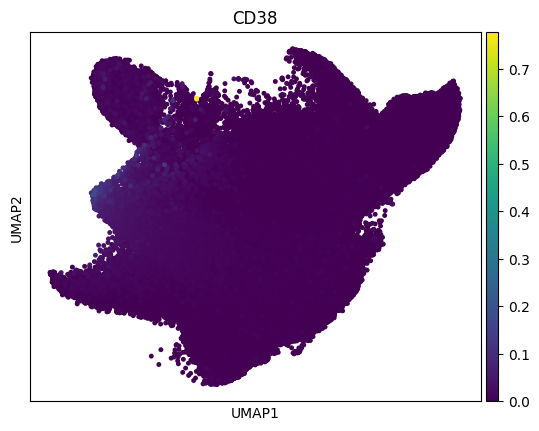

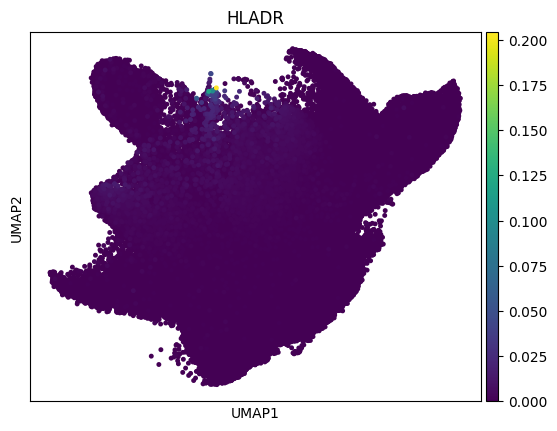

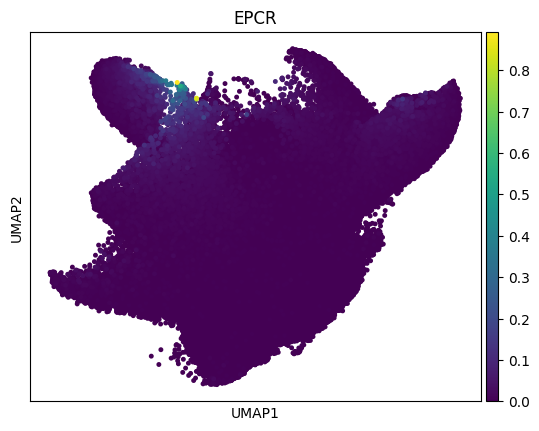

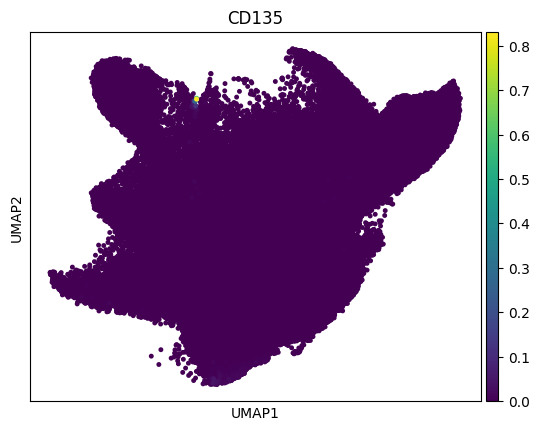

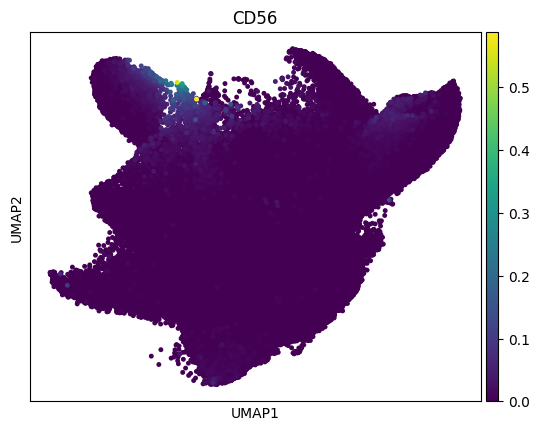

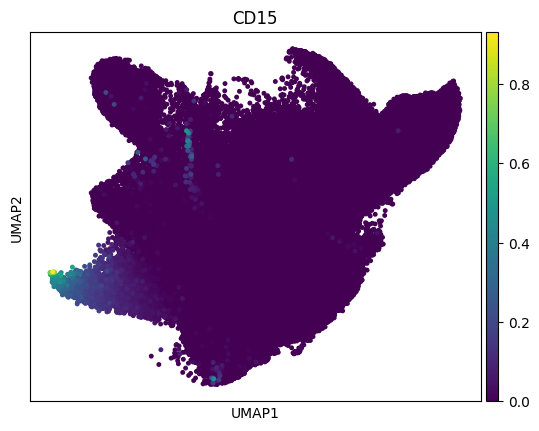

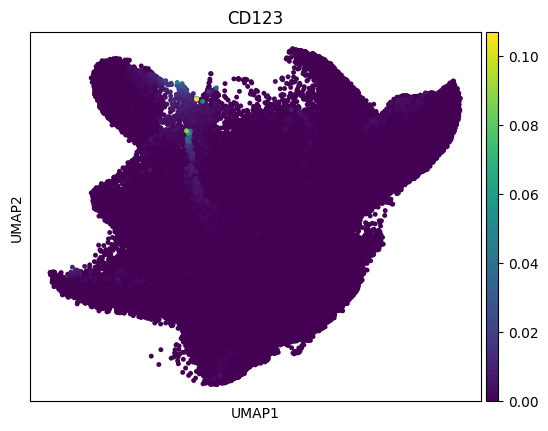

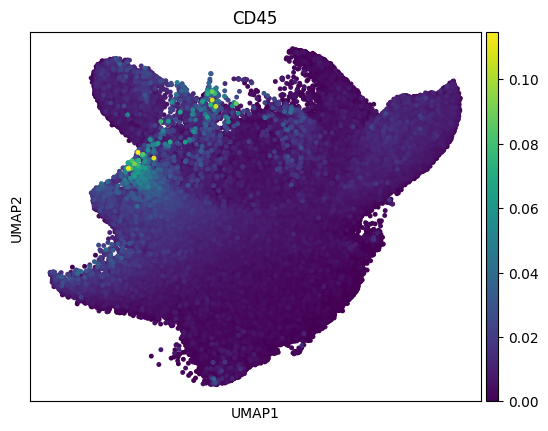

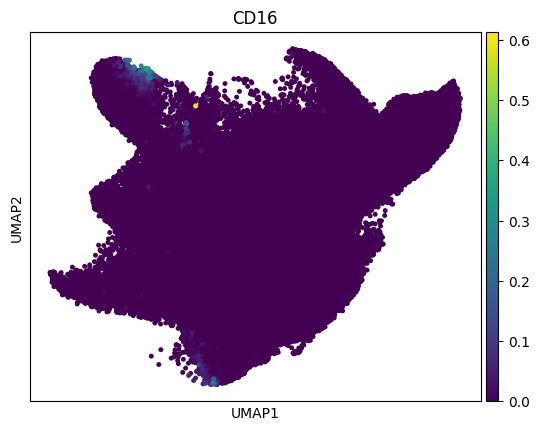

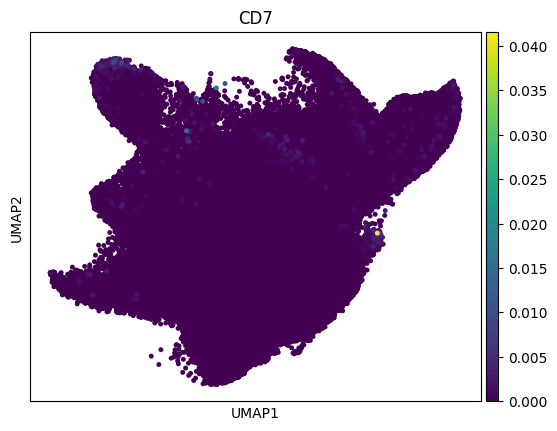

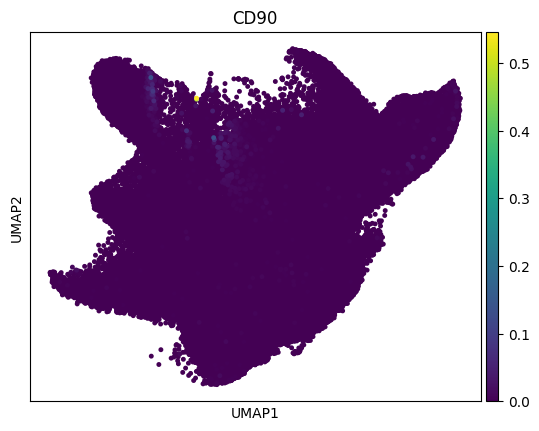

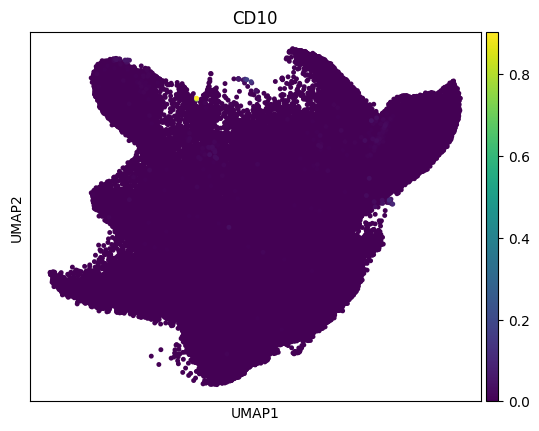

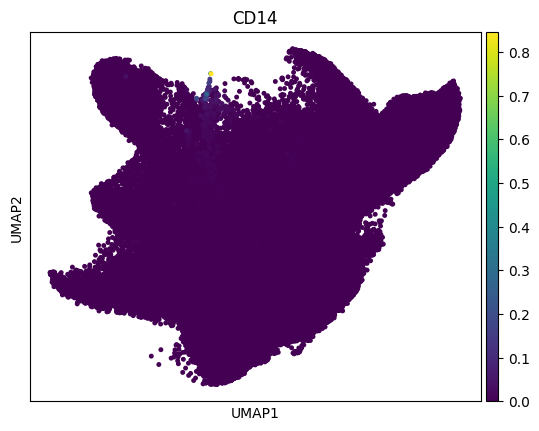

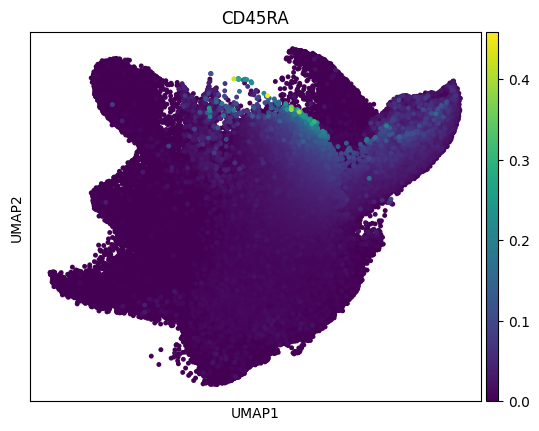

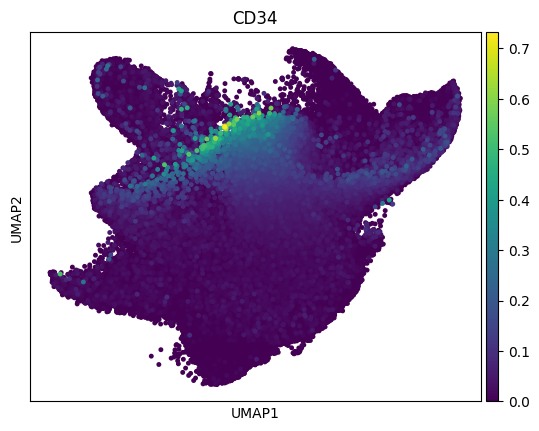

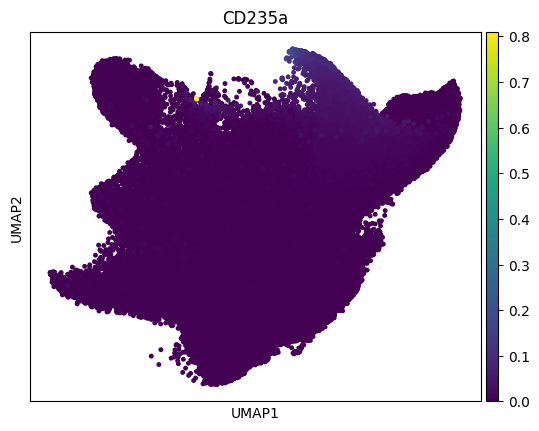

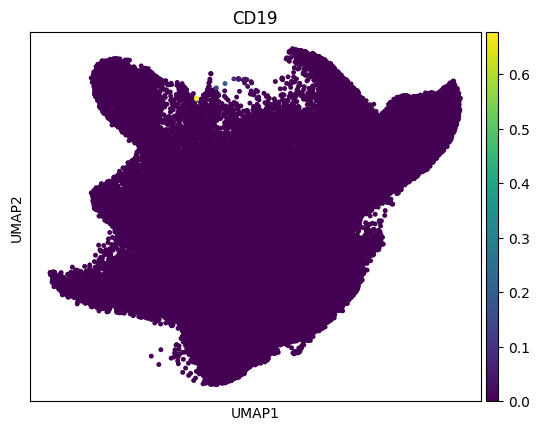

In [192]:
for marker in adata_mgk.var.index:
    sc.pl.umap(adata_mgk, color=marker, s=50)

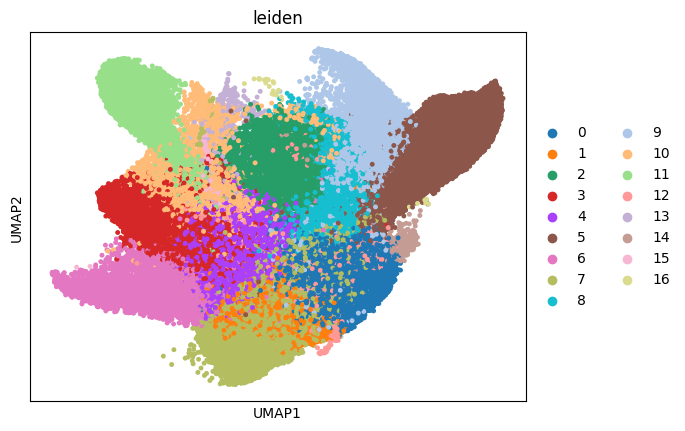

In [193]:
sc.pl.umap(adata_mgk, color="leiden", s=50)

## Check comparison CD41a 

In [194]:
cd41a_df = {"CD41a": adata_mgk[:,"CD41a"].X.toarray().ravel(), 
           "experiment_number": adata_mgk.obs["experiment_number"].values}

In [195]:
cd41a_df = pd.DataFrame(cd41a_df)

<Axes: xlabel='experiment_number', ylabel='CD41a'>

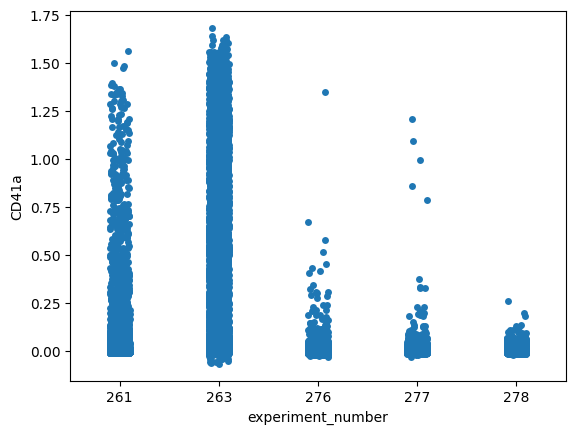

In [196]:
sns.stripplot(cd41a_df, x="experiment_number", y="CD41a")

# Classification 

In [171]:
with initialize(config_path="../../../inverse/loss_guidance/config", version_base=None):
    config = compose(config_name="run_inverse",
                    overrides=[
                        "paths=bloodplus_fm"
                    ])

ANNOTATION_CFG_FILE = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/loss_guidance/config/annotation/default.yaml"
with open(ANNOTATION_CFG_FILE, "r") as fb:
    annotation_cfg = yaml.safe_load(fb)
protocol_cols = annotation_cfg["protocol_columns"]

logger = logging.getLogger(__name__)

forward_model, (
    flow_matching,
    target_prediction_model
) = get_forward_model(config, logger=logger)

In [197]:
# Standardization parameters 
train_adata_g = target_prediction_model.train_data.adata
scatter_params = train_adata_g.uns["X_scatter_params"]
channel_params = train_adata_g.uns["X_channel_params"]
scatter_params.keys(), channel_params.keys()

adata_mgk.obs.columns = [
    col.split(' :: ')[-1] if ' :: ' in col else col
    for col in adata_mgk.obs.columns
]

In [198]:
X_channel = adata_mgk.X
X_channel = (X_channel - channel_params["mean"])/channel_params["std"]
X_scatter = []

for col in config.annotation.scatter_columns:
    col_vals = adata_mgk.obs[col].astype(float).values
    X_scatter.append(col_vals)
    
X_scatter = np.stack(X_scatter, axis=1)
X_scatter = (X_scatter - scatter_params["mean"])/scatter_params["std"]

X = np.concatenate(
    (
        X_channel, X_scatter
    ), axis=1
)

print(f"{X_channel.shape=} {X_scatter.shape=}")

X_channel.shape=(125000, 20) X_scatter.shape=(125000, 6)


In [199]:
dataloader = DataLoader(
    torch.utils.data.TensorDataset(torch.from_numpy(X)), 
    batch_size=4026,
    shuffle=False
)

ct_predictions = []

with torch.no_grad():
    for batch in tqdm(dataloader):
        X_batch = batch[0].to(target_prediction_model.device).to(torch.float32)
        y_pred = target_prediction_model.predict(X_batch)["cell_type"].argmax(1)
        ct_predictions.append(y_pred.cpu().detach().numpy())
ct_predictions = np.concatenate(ct_predictions)

100%|██████████| 32/32 [00:00<00:00, 54.67it/s]


In [200]:
# Prepare label encoder
ct_le = LabelEncoder()
ct_values = train_adata_g.obs["cell_type"].values
ct_le.fit(ct_values)
classes = np.array(ct_le.classes_.tolist())

In [201]:
ct_predictions_str = classes[ct_predictions]
adata_mgk.obs["cell_type"] = ct_predictions_str

/tmp/ipykernel_2369460/1121536839.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_mgk.obs["cell_type"] = ct_predictions_str


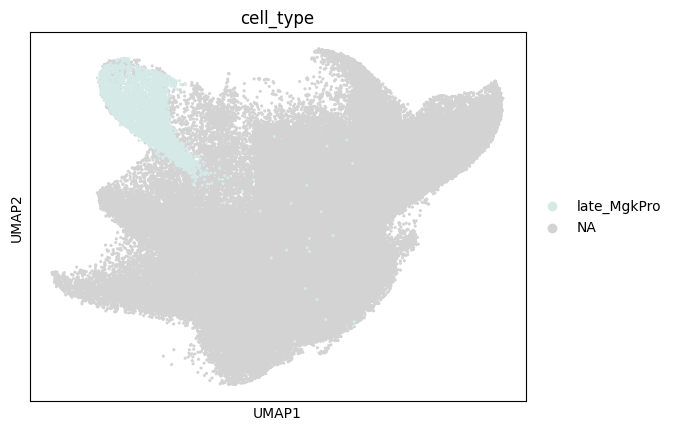

In [202]:
sc.pl.umap(adata_mgk, color="cell_type", s=20, groups="late_MgkPro")

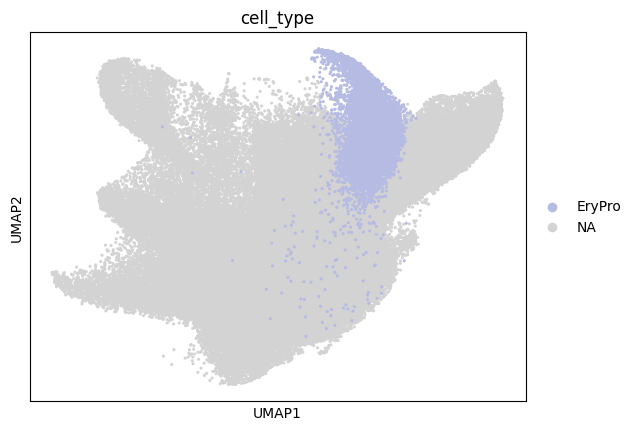

In [203]:
sc.pl.umap(adata_mgk, color="cell_type", s=20, groups="EryPro")

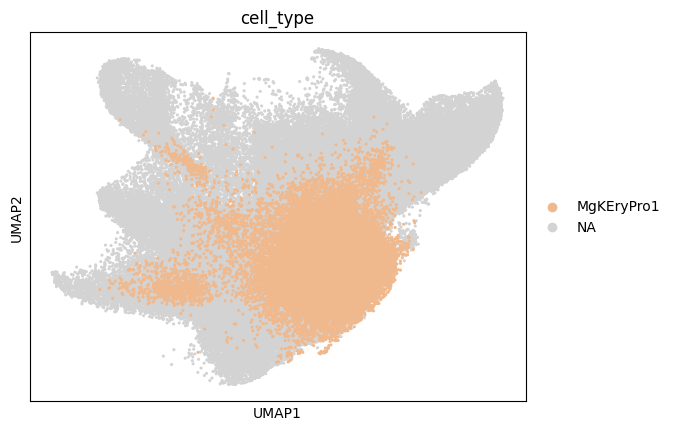

In [204]:
sc.pl.umap(adata_mgk, color="cell_type", s=20, groups="MgKEryPro1")

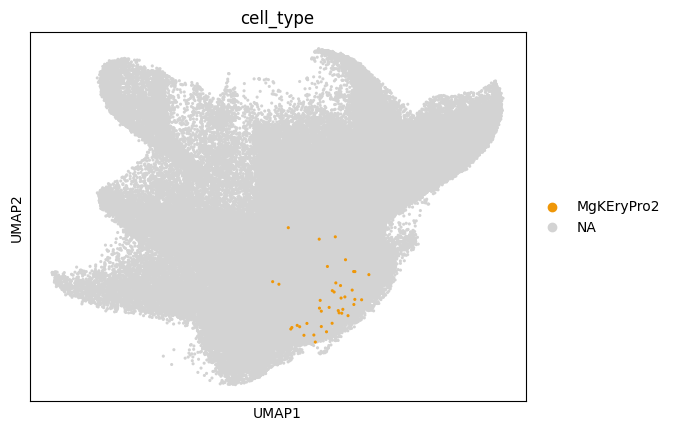

In [205]:
sc.pl.umap(adata_mgk, color="cell_type", s=20, groups="MgKEryPro2")

## Plot cell type props

In [206]:
unique_ct = np.unique(adata_mgk.obs["cell_type"])

In [207]:
props_per_exp = {"Exp": [], 
                "prop_mgk": [], 
                "prop_mgk_lin": []}

for exp in experiments:
    adata_mgk_exp = adata_mgk[adata_mgk.obs["experiment_number"]==exp]
    props = adata_mgk_exp.obs.cell_type.value_counts()
    props = props / props.sum()

    for ct in classes: 
        if ct not in props.index:
            props[ct] = 0

    props_per_exp["Exp"].append(exp)
    props_per_exp["prop_mgk"].append(props["late_MgkPro"])    
    props_per_exp["prop_mgk_lin"].append(props["late_MgkPro"] + props["MgKEryPro1"] + props["MgKEryPro2"])

In [208]:
props_per_exp_df = pd.DataFrame(props_per_exp)

In [209]:
neg_control_row = (
    props_per_exp_df[props_per_exp_df.Exp.isin(["276", "277", "278"])]
    .drop(columns="Exp")
    .apply(pd.to_numeric, errors="coerce")
    .mean()
)
neg_control_row["Exp"] = "negative control"

props_per_exp_df = props_per_exp_df[~props_per_exp_df.Exp.isin(["276", "277", "278"])]

props_per_exp_df = pd.concat(
    [props_per_exp_df, neg_control_row.to_frame().T],
    ignore_index=True
)

props_per_exp_df

,Exp,prop_mgk,prop_mgk_lin
0,261,0.01608,0.29352
1,263,0.13328,0.29344
2,negative control,0.000347,0.14844


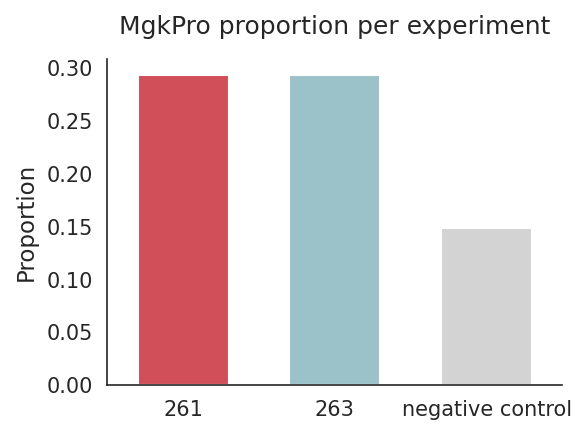

In [221]:
sns.set_style("white")

color_map = {
    "261": "#E63946",
    "263": "#94C7CF",
    "negative control": "lightgray",
}

fig, ax = plt.subplots(figsize=(4, 3), dpi=150)

sns.barplot(
    props_per_exp_df,
    x="Exp",
    y="prop_mgk_lin",
    hue="Exp",
    palette=color_map,
    legend=False,
    width=0.6,
    ax=ax
)

ax.set_xlabel("")
ax.set_ylabel("Proportion", fontsize=11)
ax.set_title("MgkPro proportion per experiment", fontsize=12, pad=12)
sns.despine(ax=ax)
ax.tick_params(axis="both", labelsize=10)

plt.tight_layout()
fig.savefig("prop_mgk_lin_barplot.png", dpi=300, bbox_inches="tight")
plt.show()

In [211]:
# sns.barplot(props_per_exp_df, x="Exp", y="prop_mgk")

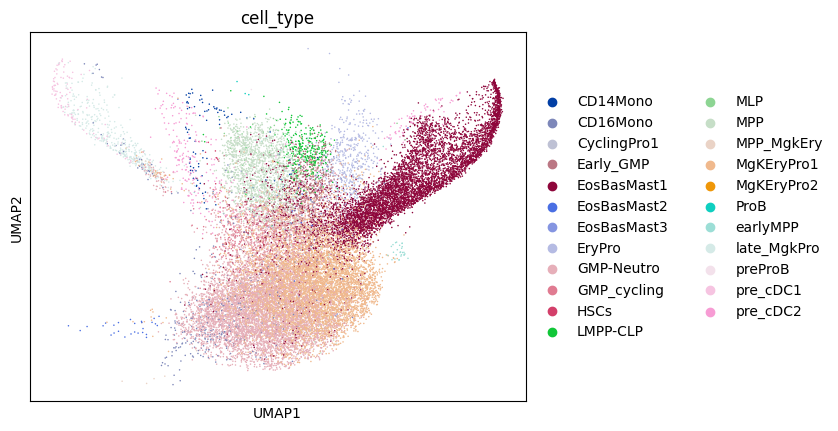

In [45]:
sc.pl.umap(adata_mgk[adata_mgk.obs.experiment_number=="261"], color="cell_type")

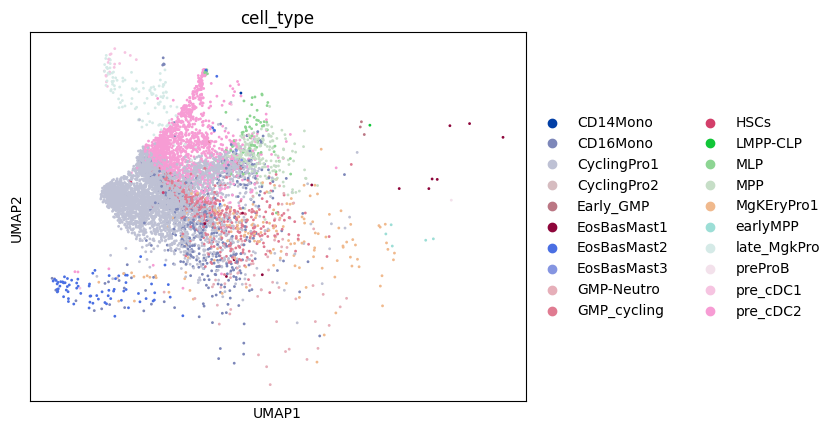

In [46]:
sc.pl.umap(adata_mgk[adata_mgk.obs.experiment_number=="262"], color="cell_type")

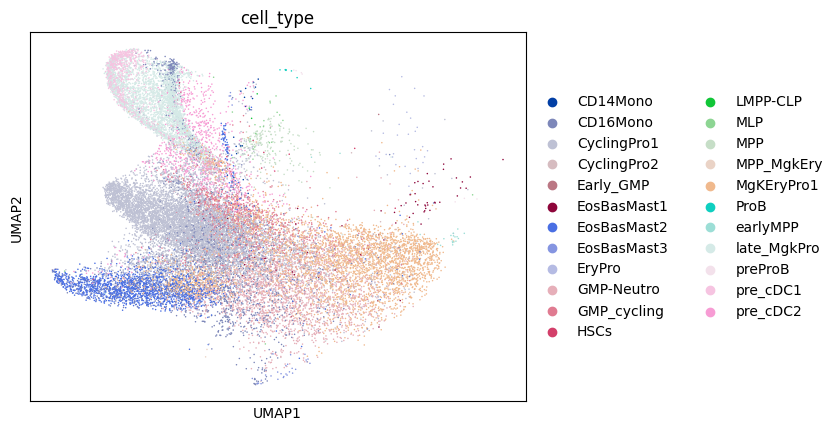

In [47]:
sc.pl.umap(adata_mgk[adata_mgk.obs.experiment_number=="263"], color="cell_type")